# Phase 1: Exploratory Data Analysis (EDA)

**Overview**
- Datasets: **CIFAKE** + **DeepDetect-2025**
- Understand distribution, quality, and characteristics of both datasets
- Visualize sample images (real vs. fake)
- Check class imbalance, resolution differences, and obvious artifacts
- Document findings for model design

This notebook is meant to run **locally** (VS Code, Jupyter, etc.). Point **`DATA_ROOT`** at a folder that contains `cifake/` and `deepdetect_2025/`. By default it uses `datasets/` under the project root when the kernel working directory is the repo root or `EDA/`.

**Expected layout under `DATA_ROOT`**

```
DATA_ROOT/
  cifake/          # e.g. train/REAL, train/FAKE, test/...
  deepdetect_2025/
```

**Sources**

| Dataset | Notes | Link(s) |
|---------|--------|---------|
| **CIFAKE** | 100k train / 20k test, 32×32, REAL (CIFAR-10) vs FAKE (Stable Diffusion 1.4) | [GitHub](https://github.com/jordan-bird/CIFAKE-Real-and-AI-Generated-Synthetic-Images), [Kaggle](https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images) |
| **DeepDetect-2025** | 90.4k train / 21.8k test, 256×256 | [Kaggle](https://www.kaggle.com/datasets/ayushmandatta1/deepdetect-2025) |


## 1. Install Dependencies


In [1]:
%pip install -q pillow numpy pandas matplotlib seaborn tqdm


Note: you may need to restart the kernel to use updated packages.


## 2. Imports


In [2]:
from __future__ import annotations

import os
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageStat
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
rng = random.Random(42)
np.random.seed(42)


## 3. Data paths

Set **`DATA_ROOT`** manually if the default is wrong. By default, `resolve_data_root()` looks for `datasets/` in the current working directory or one level up from `EDA/`.


In [17]:
def resolve_data_root() -> Path:
    """Prefer project datasets/ when cwd is repo root or EDA/."""
    cwd = Path.cwd().resolve()
    if (cwd / "datasets").is_dir():
        return cwd / "datasets"
    if cwd.name == "EDA" and (cwd.parent / "datasets").is_dir():
        return cwd.parent / "datasets"
    return cwd / "datasets"


DATA_ROOT = resolve_data_root()
# Optional: uncomment to set an explicit folder (Windows paths OK):
# DATA_ROOT = Path(r"C:\Users\you\project\datasets")

CIFAKE_DIR = DATA_ROOT / "cifake"
DEEPDETECT_DIR = DATA_ROOT / "deepdetect_2025"

# RGB mean/std: sampled per class (full-res scan is expensive). Resolution uses every train image.
RGB_STATS_PER_CLASS = 500
GRID_N = 12

if not DATA_ROOT.is_dir():
    raise FileNotFoundError(
        f"DATA_ROOT does not exist: {DATA_ROOT}\n"
        "Create it or set DATA_ROOT to your folder containing cifake/ and deepdetect_2025/."
    )
for name, d in [("CIFAKE", CIFAKE_DIR), ("DeepDetect-2025", DEEPDETECT_DIR)]:
    if not d.is_dir():
        raise FileNotFoundError(f"{name} directory missing: {d}")
    if not any(d.iterdir()):
        raise FileNotFoundError(f"{name} directory is empty: {d}")

print("DATA_ROOT      =", DATA_ROOT.resolve())
print("CIFAKE_DIR     =", CIFAKE_DIR.resolve())
print("DEEPDETECT_DIR =", DEEPDETECT_DIR.resolve())


DATA_ROOT      = C:\Users\nickz\Downloads\_SJSU Classes\CMPE 258\project\Deepfake-Classification-DeepLearning\datasets
CIFAKE_DIR     = C:\Users\nickz\Downloads\_SJSU Classes\CMPE 258\project\Deepfake-Classification-DeepLearning\datasets\cifake
DEEPDETECT_DIR = C:\Users\nickz\Downloads\_SJSU Classes\CMPE 258\project\Deepfake-Classification-DeepLearning\datasets\deepdetect_2025


## 4. Helpers (paths, counts, plots)


In [15]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif"}


def is_image_path(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMAGE_EXTS


def print_cifake_deepdetect_layout(root: Path, n_example_files: int = 2) -> None:
    """CIFAKE / DeepDetect only: train|test / REAL|FAKE|real|fake + a few sample filenames."""
    if not root.is_dir():
        print(f"Not a directory: {root}")
        return
    print(f"{root.name}/  ({root.resolve()})")
    saw_split = False
    for split in ("train", "test"):
        d_split = root / split
        if not d_split.is_dir():
            continue
        saw_split = True
        print(f"  {split}/")
        saw_class = False
        for cls_dir in sorted(d_split.iterdir(), key=lambda p: p.name.lower()):
            if not cls_dir.is_dir() or cls_dir.name.lower() not in {"real", "fake"}:
                continue
            saw_class = True
            print(f"    {cls_dir.name}/")
            try:
                names = sorted(
                    (x.name for x in cls_dir.iterdir() if x.is_file() and x.suffix.lower() in IMAGE_EXTS),
                    key=str.lower,
                )
            except OSError:
                names = []
            for fn in names[:n_example_files]:
                print(f"      {fn}")
            if len(names) > n_example_files:
                print(f"      ... ({len(names)} images)")
            elif not names:
                print("      (no image files)")
        if not saw_class:
            print("    (no REAL|FAKE|real|fake class folder)")
    if not saw_split:
        print("  (no train/ or test/)")


def count_images_under(root: Path) -> int:
    n = 0
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if Path(fn).suffix.lower() in IMAGE_EXTS:
                n += 1
    return n


def find_labeled_split_dirs(dataset_root: Path) -> list[tuple[str, str, Path]]:
    out: list[tuple[str, str, Path]] = []
    if not dataset_root.exists():
        return out
    for p in dataset_root.rglob("*"):
        if not p.is_dir():
            continue
        name = p.name.lower()
        if name in {"real", "0", "authentic"}:
            label = "REAL"
        elif name in {"fake", "1", "ai", "synthetic", "generated"}:
            label = "FAKE"
        else:
            continue
        parts = {x.lower() for x in p.parts}
        split = "all"
        for sp in ["train", "test", "val", "valid", "validation"]:
            if sp in parts:
                split = sp
                break
        n = count_images_under(p)
        if n == 0:
            continue
        out.append((split, label, p))
    seen: set[Path] = set()
    uniq: list[tuple[str, str, Path]] = []
    for item in out:
        key = item[2].resolve()
        if key in seen:
            continue
        seen.add(key)
        uniq.append(item)
    return uniq


def find_deepdetect_labeled_dirs(dataset_root: Path) -> list[tuple[str, str, Path]]:
    """Only folders named real or fake (case-insensitive), under train|test|val|... or dataset root."""
    out: list[tuple[str, str, Path]] = []
    if not dataset_root.is_dir():
        return out
    for sp in ["train", "test", "val", "valid", "validation"]:
        split_root = dataset_root / sp
        if not split_root.is_dir():
            continue
        for child in split_root.iterdir():
            if not child.is_dir():
                continue
            low = child.name.lower()
            if low == "real":
                label = "REAL"
            elif low == "fake":
                label = "FAKE"
            else:
                continue
            if count_images_under(child) > 0:
                out.append((sp, label, child))
    for child in sorted(dataset_root.iterdir()):
        if not child.is_dir():
            continue
        low = child.name.lower()
        if low == "real":
            label = "REAL"
        elif low == "fake":
            label = "FAKE"
        else:
            continue
        if count_images_under(child) > 0:
            out.append(("all", label, child))
    seen: set[Path] = set()
    uniq: list[tuple[str, str, Path]] = []
    for item in out:
        key = item[2].resolve()
        if key in seen:
            continue
        seen.add(key)
        uniq.append(item)
    return uniq


def build_counts_table(
    dataset_root: Path,
    labeled: list[tuple[str, str, Path]] | None = None,
) -> pd.DataFrame:
    rows = []
    labeled = labeled if labeled is not None else find_labeled_split_dirs(dataset_root)
    if labeled:
        for split, label, d in labeled:
            rows.append(
                {
                    "split": split,
                    "label": label,
                    "dir": str(d),
                    "n_images": count_images_under(d),
                }
            )
        return pd.DataFrame(rows).sort_values(["split", "label"]).reset_index(drop=True)
    for child in sorted(dataset_root.iterdir()):
        if child.is_dir():
            rows.append(
                {
                    "split": "unknown",
                    "label": child.name,
                    "dir": str(child),
                    "n_images": count_images_under(child),
                }
            )
    return pd.DataFrame(rows)


def gather_image_paths(label_dir: Path, limit: int | None = None) -> list[Path]:
    paths: list[Path] = []
    for dirpath, _, filenames in os.walk(label_dir):
        for fn in filenames:
            p = Path(dirpath) / fn
            if is_image_path(p):
                paths.append(p)
                if limit is not None and len(paths) >= limit:
                    return paths
    return paths


def sample_images_for_class_dirs(
    dataset_root: Path,
    per_class: int,
    labeled: list[tuple[str, str, Path]] | None = None,
) -> dict[str, list[Path]]:
    labeled = labeled if labeled is not None else find_labeled_split_dirs(dataset_root)
    has_train = any(s == "train" for s, _, _ in labeled)
    buckets: dict[str, list[Path]] = defaultdict(list)
    for split, label, d in labeled:
        if has_train and split not in {"train", "all"}:
            continue
        paths = gather_image_paths(d)
        rng.shuffle(paths)
        buckets[label].extend(paths[:per_class])
    for k in list(buckets.keys()):
        buckets[k] = buckets[k][:per_class]
    return dict(buckets)


def iter_image_paths_for_stats(label_dir: Path, max_images: int | None = None) -> list[Path]:
    return gather_image_paths(label_dir, limit=max_images)


def rgb_means_stds(paths: list[Path]) -> tuple[np.ndarray, np.ndarray]:
    means, stds = [], []
    for p in tqdm(paths, desc="RGB stats", leave=False):
        try:
            with Image.open(p) as im:
                im = im.convert("RGB")
                st = ImageStat.Stat(im)
                means.append(np.array(st.mean) / 255.0)
                stds.append(np.array(st.stddev) / 255.0)
        except Exception:
            continue
    if not means:
        return np.zeros(3), np.zeros(3)
    return np.mean(means, axis=0), np.mean(stds, axis=0)


def resolution_stats(paths: list[Path]) -> pd.DataFrame:
    rows = []
    for p in tqdm(paths, desc="Resolutions", leave=False):
        try:
            with Image.open(p) as im:
                w, h = im.size
                rows.append({"path": str(p), "width": w, "height": h, "aspect": w / max(h, 1)})
        except Exception as ex:
            rows.append({"path": str(p), "width": np.nan, "height": np.nan, "aspect": np.nan, "error": str(ex)})
    return pd.DataFrame(rows)


def show_image_grid(paths_by_label: dict[str, list[Path]], title: str, ncols: int = 6):
    labels = [k for k in sorted(paths_by_label.keys()) if paths_by_label[k]]
    if not labels:
        print("No images for", title)
        return
    nrows = len(labels)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2.2 * ncols, 2.5 * nrows))
    if nrows == 1:
        axes = np.array([axes])
    for r, lab in enumerate(labels):
        paths = paths_by_label[lab][:ncols]
        for c in range(ncols):
            ax = axes[r, c]
            ax.axis("off")
            if c < len(paths):
                try:
                    with Image.open(paths[c]) as im:
                        ax.imshow(im.convert("RGB"))
                except Exception as ex:
                    ax.text(0.05, 0.5, str(ex), transform=ax.transAxes, fontsize=8)
            if c == 0:
                ax.set_title(lab, loc="left", fontsize=11, fontweight="bold", pad=8)
    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.subplots_adjust(hspace=0.2)
    plt.show()


def plot_balance(df: pd.DataFrame, chart_title: str):
    if df.empty:
        print("No rows to plot:", chart_title)
        return
    t = df.copy()
    t["group"] = t["split"].astype(str) + " / " + t["label"].astype(str)
    plt.figure(figsize=(10, 4))
    order = sorted(t["group"].unique())
    sns.barplot(data=t, x="group", y="n_images", order=order, color="#4C72B0")
    plt.xticks(rotation=25, ha="right")
    plt.title(chart_title)
    plt.ylabel("Images")
    plt.tight_layout()
    plt.show()


## 5. EDA: CIFAKE

Data is read from `CIFAKE_DIR` on disk. Expected layout: `train/` and `test/`, each with `REAL`/`FAKE` class folders. The next cell prints that structure plus a couple of sample filenames per class.


In [5]:
print_cifake_deepdetect_layout(CIFAKE_DIR)


cifake/  (C:\Users\nickz\Downloads\_SJSU Classes\CMPE 258\project\Deepfake-Classification-DeepLearning\datasets\cifake)
  train/
    FAKE/
      1000 (10).jpg
      1000 (2).jpg
      ... (50000 images)
    REAL/
      0000 (10).jpg
      0000 (2).jpg
      ... (50000 images)
  test/
    FAKE/
      0 (10).jpg
      0 (2).jpg
      ... (10000 images)
    REAL/
      0000 (10).jpg
      0000 (2).jpg
      ... (10000 images)


,split,label,dir,n_images
0,test,FAKE,C:\Users\nickz\Downloads\_SJSU Classes\CMPE 25...,10000
1,test,REAL,C:\Users\nickz\Downloads\_SJSU Classes\CMPE 25...,10000
2,train,FAKE,C:\Users\nickz\Downloads\_SJSU Classes\CMPE 25...,50000
3,train,REAL,C:\Users\nickz\Downloads\_SJSU Classes\CMPE 25...,50000


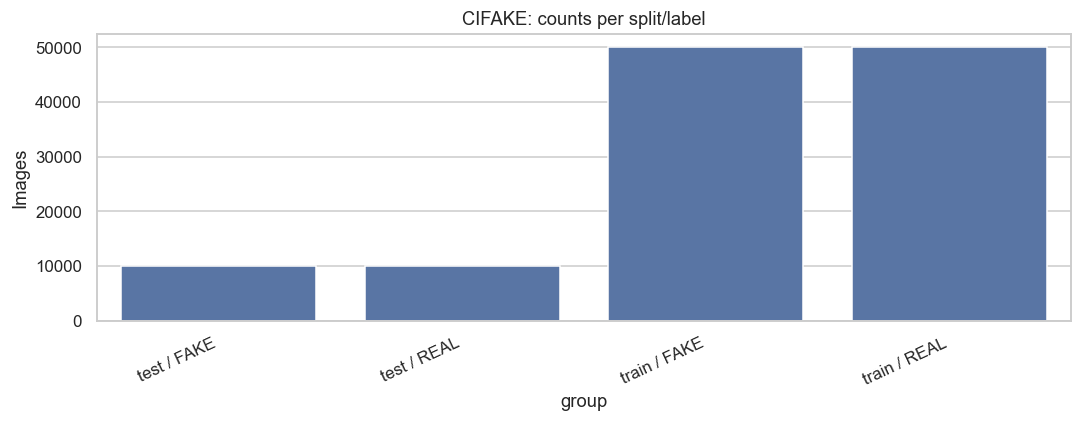

In [6]:
cifake_counts = build_counts_table(CIFAKE_DIR)
display(cifake_counts)
plot_balance(cifake_counts, "CIFAKE: counts per split/label")


CIFAKE resolution: 100000 images (full train set)


Resolutions:   0%|          | 0/100000 [00:00<?, ?it/s]

,width,height,aspect
count,100000.0,100000.0,100000.0
mean,32.0,32.0,1.0
std,0.0,0.0,0.0
min,32.0,32.0,1.0
25%,32.0,32.0,1.0
50%,32.0,32.0,1.0
75%,32.0,32.0,1.0
max,32.0,32.0,1.0


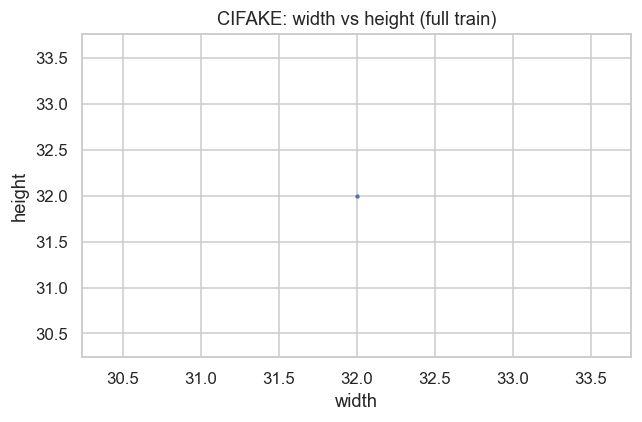

NameError: name 'RGB_STATS_PER_CLASS' is not defined

In [ ]:
labeled = find_labeled_split_dirs(CIFAKE_DIR)
train_dirs = [(lab, d) for s, lab, d in labeled if s == "train"]
if not train_dirs:
    train_dirs = [(lab, d) for s, lab, d in labeled]

paths_resolution: list[Path] = []
for lab, d in train_dirs:
    paths_resolution.extend(gather_image_paths(d))
print(f"CIFAKE resolution: {len(paths_resolution)} images (full train set)")

res_df = resolution_stats(paths_resolution)
display(res_df[["width", "height", "aspect"]].describe())

plt.figure(figsize=(6, 4))
sns.scatterplot(data=res_df.dropna(subset=["width", "height"]), x="width", y="height", alpha=0.25, s=8)
plt.title("CIFAKE: width vs height (full train)")
plt.tight_layout()
plt.show()


In [22]:
by_lab: dict[str, list[Path]] = defaultdict(list)
for p in paths_resolution:
    by_lab[p.parent.name.upper()].append(p)
for lab in ("REAL", "FAKE"):
    pts = by_lab.get(lab, [])
    rng.shuffle(pts)
    pts = pts[:RGB_STATS_PER_CLASS]
    if pts:
        m, s = rgb_means_stds(pts)
        print(lab, "\n", f"mean RGB (up to {RGB_STATS_PER_CLASS} sampled):", np.round(m, 4), "\n", "mean channel std:", np.round(s, 4))


RGB stats:   0%|          | 0/500 [00:00<?, ?it/s]

REAL 
 mean RGB (up to 500 sampled): [0.4938 0.4785 0.4396] 
 mean channel std: [0.2055 0.2026 0.2058]


RGB stats:   0%|          | 0/500 [00:00<?, ?it/s]

FAKE 
 mean RGB (up to 500 sampled): [0.452  0.4414 0.391 ] 
 mean channel std: [0.2076 0.2058 0.2035]


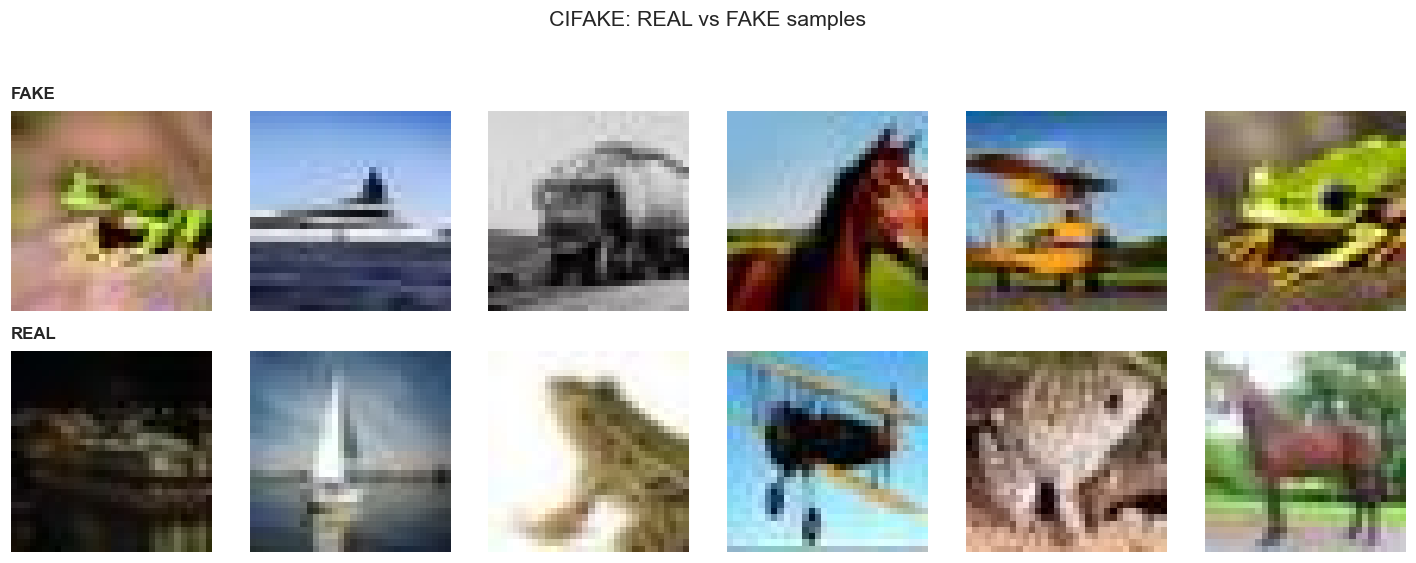

In [8]:
sampled_cifake = sample_images_for_class_dirs(CIFAKE_DIR, per_class=GRID_N)
show_image_grid(sampled_cifake, "CIFAKE: REAL vs FAKE samples", ncols=6)


## 6. EDA: DeepDetect-2025

Data is read from `DEEPDETECT_DIR` on disk. This section uses **`find_deepdetect_labeled_dirs`** for counts/plots (only **`real`** / **`fake`** class folders). Expected on-disk layout matches CIFAKE: `train|test` then class dirs. The next cell prints that layout plus sample filenames.


In [9]:
print_cifake_deepdetect_layout(DEEPDETECT_DIR)


deepdetect_2025/  (C:\Users\nickz\Downloads\_SJSU Classes\CMPE 258\project\Deepfake-Classification-DeepLearning\datasets\deepdetect_2025)
  train/
    fake/
      fake_000000.jpg
      fake_000001.jpg
      ... (41594 images)
    real/
      00000.jpg
      00002.jpg
      ... (48815 images)
  test/
    fake/
      fake_041594.jpg
      fake_041595.jpg
      ... (10399 images)
    real/
      real_045504.jpg
      real_045505.jpg
      ... (11377 images)


,split,label,dir,n_images
0,test,FAKE,C:\Users\nickz\Downloads\_SJSU Classes\CMPE 25...,10399
1,test,REAL,C:\Users\nickz\Downloads\_SJSU Classes\CMPE 25...,11377
2,train,FAKE,C:\Users\nickz\Downloads\_SJSU Classes\CMPE 25...,41594
3,train,REAL,C:\Users\nickz\Downloads\_SJSU Classes\CMPE 25...,48815


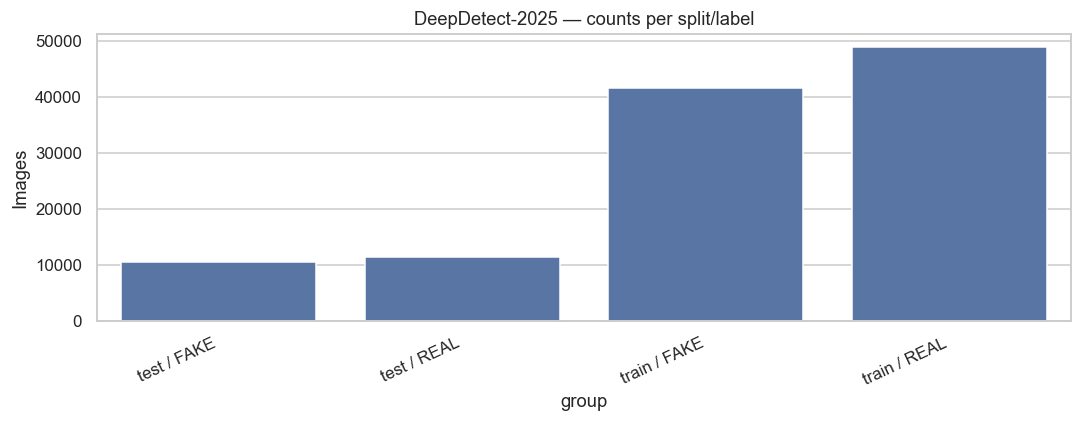

In [23]:
dd_labeled = find_deepdetect_labeled_dirs(DEEPDETECT_DIR)
dd_counts = build_counts_table(DEEPDETECT_DIR, labeled=dd_labeled)
display(dd_counts)
plot_balance(dd_counts, "DeepDetect-2025 — counts per split/label")


DeepDetect resolution: 90409 images (full train set)


Resolutions:   0%|          | 0/90409 [00:00<?, ?it/s]

,width,height,aspect
count,90409.000000,90409.000000,90409.000000
mean,257.339291,257.300479,1.000073
std,23.862147,22.657452,0.023677
min,161.000000,144.000000,0.500000
25%,256.000000,256.000000,1.000000
50%,256.000000,256.000000,1.000000
75%,256.000000,256.000000,1.000000
max,1152.000000,1408.000000,1.906542


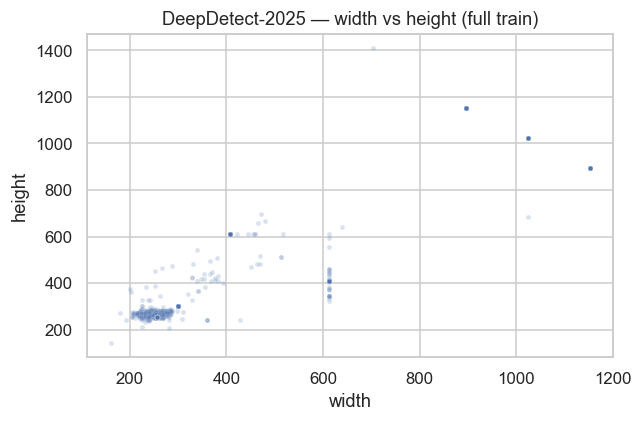

In [24]:
labeled_dd = find_deepdetect_labeled_dirs(DEEPDETECT_DIR)
train_dd = [(lab, d) for s, lab, d in labeled_dd if s == "train"]
if not train_dd:
    train_dd = [(lab, d) for s, lab, d in labeled_dd]

paths_dd: list[Path] = []
for lab, d in train_dd:
    paths_dd.extend(gather_image_paths(d))
print(f"DeepDetect resolution: {len(paths_dd)} images (full train set)")

if paths_dd:
    res_dd = resolution_stats(paths_dd)
    display(res_dd[["width", "height", "aspect"]].describe())
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=res_dd.dropna(subset=["width", "height"]), x="width", y="height", alpha=0.2, s=10)
    plt.title("DeepDetect-2025 — width vs height (full train)")
    plt.tight_layout()
    plt.show()
else:
    print("No image paths found — inspect DEEPDETECT_DIR and adjust folder naming in helpers if needed.")


In [25]:
by_lab: dict[str, list[Path]] = defaultdict(list)
for p in paths_dd:
    by_lab[p.parent.name.upper()].append(p)
for lab in ("REAL", "FAKE"):
    pts = by_lab.get(lab, [])
    rng.shuffle(pts)
    pts = pts[:RGB_STATS_PER_CLASS]
    if pts:
        m, s = rgb_means_stds(pts)
        print(lab, "\n", f"mean RGB (up to {RGB_STATS_PER_CLASS} sampled):", np.round(m, 4), "\n", "mean channel std:", np.round(s, 4))


RGB stats:   0%|          | 0/500 [00:00<?, ?it/s]

REAL 
 mean RGB (up to 500 sampled): [0.5134 0.4212 0.3753] 
 mean channel std: [0.2556 0.227  0.2228]


RGB stats:   0%|          | 0/500 [00:00<?, ?it/s]

FAKE 
 mean RGB (up to 500 sampled): [0.5295 0.4346 0.3903] 
 mean channel std: [0.2418 0.2215 0.2195]


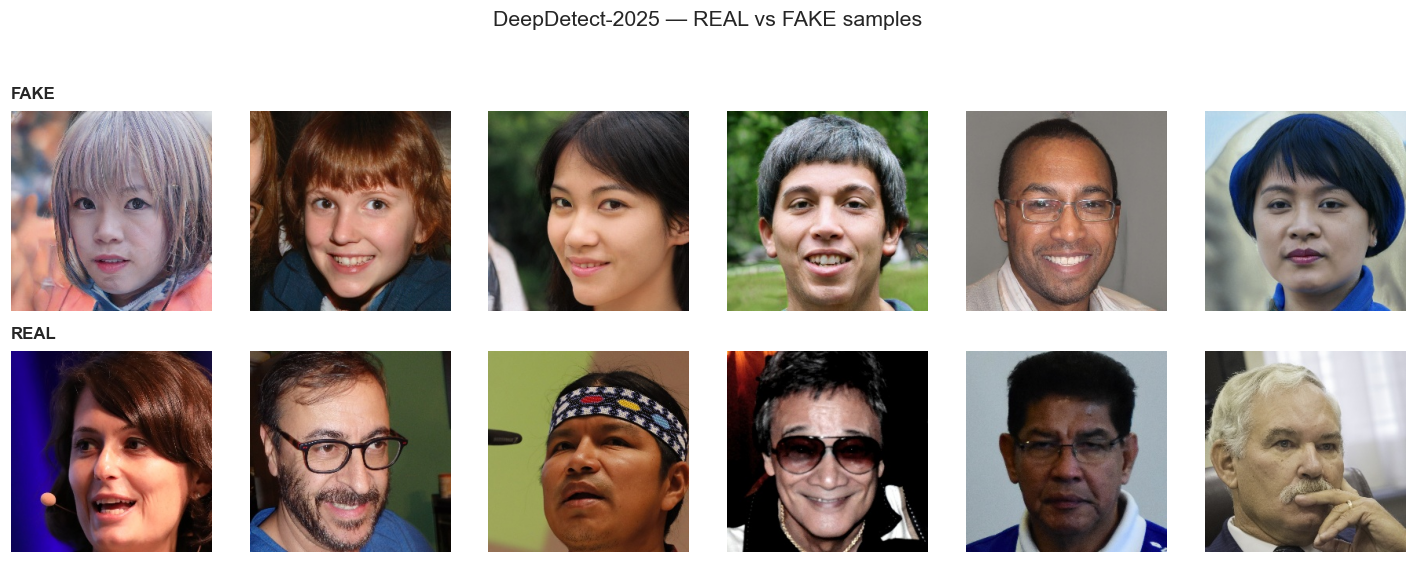

In [12]:
sampled_dd = sample_images_for_class_dirs(DEEPDETECT_DIR, per_class=GRID_N, labeled=labeled_dd)
show_image_grid(sampled_dd, "DeepDetect-2025 — REAL vs FAKE samples", ncols=6)


## 7. Side-by-side summary


In [13]:
summary = pd.DataFrame(
    [
        {
            "dataset": "CIFAKE",
            "labeled_groups": int(cifake_counts.shape[0]),
            "total_images_est": int(cifake_counts["n_images"].sum()) if not cifake_counts.empty else 0,
        },
        {
            "dataset": "DeepDetect-2025",
            "labeled_groups": int(dd_counts.shape[0]),
            "total_images_est": int(dd_counts["n_images"].sum()) if not dd_counts.empty else 0,
        },
    ]
)
display(summary)


,dataset,labeled_groups,total_images_est
0,CIFAKE,4,120000
1,DeepDetect-2025,4,112185


## 8. Findings

1. **Class balance**

- CIFAKE: balanced
- DeepDetect-2025: compared to fake images, there are about 17% more real images in the training set and 9% more in the test set

2. **Resolution**

- CIFAKE: always 32x32
- DeepDetect-2025: 

3. **Artifacts / domain**

- ???

4. **Modeling notes**

- ???
